# Resonance Peak Analysis

This notebook extracts two values from each transmission time series:

- `v1`: the maximum value of the full time series.
- `v2`: the maximum value on the other side of the resonance crossing.

For simulations, the resonance coordinate is computed directly as `detuning - df`, so resonance crossings are zero crossings of that array. For experimental traces, the resonance coordinate is not stored in the raw files, so the crossing is inferred from the transmission shape by finding the two peak-height families visible in the trace. Use the diagnostic plots at the bottom to verify that the inferred `v2` matches the feature you want.

In [152]:
from pathlib import Path
import csv
import json
import os
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

try:
    import pandas as pd
except ImportError:
    pd = None

analysis_dir = Path.cwd().resolve()
if analysis_dir.name != "analysis_rhs":
    analysis_dir = (analysis_dir / "Python" / "analysis_rhs").resolve()

python_dir = analysis_dir.parents[0]
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))

import integration.rhs as rhs

In [153]:
# Configuration copied from phase_diagrams_experiments.ipynb and phase_diagrams.ipynb.
POWER_MV = 380
CALIBRATION_JSON = Path("C:/Users/emore/OneDrive/Bouwmeester Group/data/calibration/converted_data.json")
EXPERIMENT_BASE = Path("C:/Users/emore/OneDrive/Bouwmeester Group/data/lasing_one_mode")
EXPERIMENT_FOLDER = EXPERIMENT_BASE / f"{POWER_MV}mVPM"

SIMULATION_FOLDER = Path("D:/repos/superfluid-dynamics/data/tau/damping")
SIM_INTENSITY = 380
SIM_TAU = 55e-6
SIM_DEPTH = 15e-9
SIM_DAMPING = -2.50e0
SIM_L = 100e-6
SIM_SKIP_FIRST_US = 15000
SIM_GAMMA = 20e6

# Peak-finding controls. Increase prominence fractions if noisy experimental traces create spurious peaks.
EXPERIMENT_PEAK_PROMINENCE_FRACTION = 0.02
EXPERIMENT_PEAK_MAX_THRESHOLD = 0.12
SIMULATION_PEAK_PROMINENCE_FRACTION = 0.02
MIN_PEAK_DISTANCE_FRACTION = 0.0
EXPERIMENT_MIN_PEAK_DISTANCE_FRACTION = 0.0
SIMULATION_MIN_PEAK_DISTANCE_FRACTION = 0.01

OUTPUT_CSV = analysis_dir / "resonance_peak_summary.csv"

In [154]:
def calculate_base_units(L, depth, rho=150, alpha_hammaker=3.5e-24):
    L0 = L / (2 * np.pi)
    E0 = 3.0 * rho * alpha_hammaker / depth**4 * L0**4
    g = 3 * alpha_hammaker / depth**4
    t0 = np.sqrt(L0 / g)
    return E0, t0, L0


def interpolate(x, y, x0):
    return interp1d(x, y, fill_value="extrapolate")(x0)


def gaussian(x, x0, sigma):
    return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - x0) / sigma) ** 2)


def calculate_df(x, y, optomechanical_props):
    x0 = (np.max(x) - np.min(x)) / 2.0
    dx = (x[-1] - x[0]) / len(x)
    weights = gaussian(x, x0, optomechanical_props.sigma_optical_mode) * dx
    return np.sum(weights * y * optomechanical_props.G)


def lorentzian(delta_f, gamma, max_intensity):
    return 0.25 * gamma**2 * max_intensity / (delta_f**2 + (gamma / 2) ** 2)


def transmission_from_df(df, optomechanical_props):
    delta_f = optomechanical_props.detuning - df
    return optomechanical_props.max_intensity - lorentzian(
        delta_f,
        optomechanical_props.gamma,
        optomechanical_props.max_intensity,
    )


def exponential_moving_average(values, alpha):
    smoothed = np.zeros_like(values, dtype=float)
    smoothed[0] = values[0]
    for i in range(1, len(values)):
        smoothed[i] = alpha * values[i] + (1 - alpha) * smoothed[i - 1]
    return smoothed

In [155]:
def load_detuning_lookup(power_mv=POWER_MV, calibration_json=CALIBRATION_JSON):
    with open(calibration_json, "r") as f:
        converted_data = json.load(f)

    detuning_by_mv = {}
    detunings_hz = []
    for value in converted_data.values():
        if value["power_mV"] != power_mv:
            continue
        detuning_hz = -1 * value["detuning_mhz"] * 1e6
        detuning_by_mv[value["detuning_mV"]] = detuning_hz
        detunings_hz.append(detuning_hz)
    return detuning_by_mv, sorted(detunings_hz)


def load_experimental_records(power_mv=POWER_MV):
    detuning_by_mv, _ = load_detuning_lookup(power_mv)
    folder = EXPERIMENT_BASE / f"{power_mv}mVPM"
    records = []

    for root, _, files in os.walk(folder):
        root_path = Path(root)
        if not files or not root_path.name.endswith("mVdet"):
            continue

        detuning_mv = int(root_path.name.replace("mVdet", ""))
        detuning_hz = detuning_by_mv[detuning_mv]

        for file in files:
            if not file.endswith(".txt"):
                continue
            file_path = root_path / file
            time_s, values = np.loadtxt(file_path, delimiter=" ", unpack=True)
            records.append(
                {
                    "source": "experiment",
                    "path": file_path,
                    "time_s": time_s - np.nanmin(time_s),
                    "values": values,
                    "detuning_hz": detuning_hz,
                    "detuning_mv": detuning_mv,
                }
            )

    return sorted(records, key=lambda r: (r["detuning_hz"], str(r["path"])))


def load_simulation(filename):
    with h5py.File(filename, "r") as f:
        T = f["T"][:]
        Y = f["Y"][:]
        Yshape = Y.shape
        sim_props = rhs.CSimulationProperties(**f["sim_props"].attrs)
        optomechanical_props = rhs.COptomechanicalProperties(**f["optomechanical_props"].attrs)
        rk4_props = rhs.CRK4Options(**f["rk4_props"].attrs)
    return np.array(T), np.array(Y), Yshape, sim_props, optomechanical_props, rk4_props


def simulation_paths():
    _, detunings_hz = load_detuning_lookup(POWER_MV)
    paths = []
    for detuning_hz in detunings_hz:
        filename = (
            f"results_detuning_{detuning_hz:.3e}_pow_{SIM_INTENSITY:.3e}_"
            f"tau_{SIM_TAU:.3e}_depth_{SIM_DEPTH:.3e}_L_{SIM_L:.3e}_"
            f"dmp_{SIM_DAMPING:.3e}"
            f"_gamma_{SIM_GAMMA:.3e}"
            ".h5"
        )
        paths.append(SIMULATION_FOLDER / filename)
    return paths


def load_simulation_records(skip_first_us=SIM_SKIP_FIRST_US):
    records = []
    for path in simulation_paths():
        if not path.exists():
            print(f"Skipping missing simulation: {path}")
            continue

        T, Y, Yshape, sim_props, optomechanical_props, rk4_props = load_simulation(path)
        E0, t0, L0 = calculate_base_units(sim_props.L, sim_props.depth)
        time_s = T * t0
        keep = time_s > skip_first_us * 1e-6
        T = T[keep]
        Y = Y[keep]
        time_s = time_s[keep]

        N = Yshape[1] // 4
        x0 = 0.5 * sim_props.L
        dfs = np.zeros_like(T)
        local_y = np.zeros_like(T)

        for i in range(len(T)):
            x = Y[i, :N] * L0
            y = Y[i, N : 2 * N] * L0
            local_y[i] = interpolate(Y[i, :N], Y[i, N : 2 * N], x0 / L0) * L0
            dfs[i] = calculate_df(x, y, optomechanical_props)

        delta_f = optomechanical_props.detuning - dfs
        values = transmission_from_df(dfs, optomechanical_props)
        records.append(
            {
                "source": "simulation",
                "path": path,
                "time_s": time_s,
                "values": values,
                "resonance_signal": delta_f,
                "df_hz": dfs,
                "local_y_m": local_y,
                "detuning_hz": optomechanical_props.detuning,
                "sim_props": sim_props,
                "optomechanical_props": optomechanical_props,
                "rk4_props": rk4_props,
                "E0": E0,
                "t0": t0,
                "L0": L0,
            }
        )

    return sorted(records, key=lambda r: r["detuning_hz"])

In [156]:
def finite_sorted_series(time_s, values, extra=None):
    time_s = np.asarray(time_s, dtype=float)
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(time_s) & np.isfinite(values)
    order = np.argsort(time_s[finite])

    result = [time_s[finite][order], values[finite][order]]
    if extra is not None:
        extra = np.asarray(extra, dtype=float)
        result.append(extra[finite][order])
    return result


def crossing_indices(signal):
    signal = np.asarray(signal, dtype=float)
    finite = np.isfinite(signal)
    idx = np.flatnonzero(finite)
    if len(idx) < 2:
        return np.array([], dtype=int)

    valid_signal = signal[idx]
    signs = np.sign(valid_signal)
    signs[signs == 0] = np.nan

    # Fill exact zeros from neighboring non-zero signs so that a point exactly at resonance
    # does not create two artificial crossings.
    for i in range(len(signs)):
        if np.isfinite(signs[i]):
            continue
        left = signs[i - 1] if i > 0 else np.nan
        right = signs[i + 1] if i + 1 < len(signs) else np.nan
        signs[i] = left if np.isfinite(left) else right

    changes = np.flatnonzero(np.diff(signs) != 0)
    return idx[changes]


def crossing_times(time_s, signal):
    times = []
    for i in crossing_indices(signal):
        y0, y1 = signal[i], signal[i + 1]
        t0, t1 = time_s[i], time_s[i + 1]
        if y1 == y0:
            times.append(t0)
        else:
            times.append(t0 - y0 * (t1 - t0) / (y1 - y0))
    return np.array(times)


def peak_indices(values, prominence_fraction=0.05, distance_fraction=MIN_PEAK_DISTANCE_FRACTION):
    values = np.asarray(values, dtype=float)
    span = np.nanmax(values) - np.nanmin(values)
    prominence = prominence_fraction * span if span > 0 else None
    distance = None if distance_fraction is None or distance_fraction <= 0 else max(1, int(len(values) * distance_fraction))
    peaks, _ = find_peaks(values, prominence=prominence, distance=distance)
    if len(peaks) == 0:
        peaks = np.array([int(np.nanargmax(values))])
    return peaks


def split_lower_peak_family(peak_values, threshold = None):
    peak_values = np.asarray(peak_values, dtype=float)
    if len(peak_values) < 2:
        return np.array([], dtype=bool)

    sorted_values = np.sort(peak_values)
    gaps = np.diff(sorted_values)
    if len(gaps) == 0 or np.nanmax(gaps) <= 0:
        return np.zeros(len(peak_values), dtype=bool)

    split_value = 0.5 * (sorted_values[np.argmax(gaps)] + sorted_values[np.argmax(gaps) + 1])
    if threshold is not None:
        split_value = min(split_value, threshold)
    return peak_values <= split_value


def finite_ratio(numerator, denominator):
    if not np.isfinite(numerator) or not np.isfinite(denominator) or denominator == 0:
        return np.nan
    return float(numerator / denominator)


def analyze_trace(record, prominence_fraction=0.05):
    resonance_signal = record.get("resonance_signal")
    if resonance_signal is None:
        time_s, values = finite_sorted_series(record["time_s"], record["values"])
    else:
        time_s, values, resonance_signal = finite_sorted_series(
            record["time_s"], record["values"], resonance_signal
        )

    v1_index = int(np.nanargmax(values))
    v1 = float(values[v1_index])
    v1_time_s = float(time_s[v1_index])

    method = "experimental peak-family inference"
    v2 = np.nan
    v2_time_s = np.nan
    crossing_time_values = np.array([])

    if resonance_signal is not None and len(crossing_indices(resonance_signal)) > 0:
        method = "simulation delta_f zero crossing"
        crossing_time_values = crossing_times(time_s, resonance_signal)
        sign_at_v1 = np.sign(resonance_signal[v1_index])
        if sign_at_v1 == 0:
            sign_at_v1 = np.sign(resonance_signal[np.nanargmax(np.abs(resonance_signal))])

        other_side = np.sign(resonance_signal) != sign_at_v1
        other_side &= np.sign(resonance_signal) != 0
        if np.any(other_side):
            other_indices = np.flatnonzero(other_side)
            best = other_indices[np.nanargmax(values[other_side])]
            v2 = float(values[best])
            v2_time_s = float(time_s[best])
    else:
        distance_fraction = EXPERIMENT_MIN_PEAK_DISTANCE_FRACTION if record["source"] == "experiment" else SIMULATION_MIN_PEAK_DISTANCE_FRACTION
        peaks = peak_indices(values, prominence_fraction=prominence_fraction, distance_fraction=distance_fraction)
        lower_family = split_lower_peak_family(values[peaks], threshold = EXPERIMENT_PEAK_MAX_THRESHOLD if record["source"] == "experiment" else None)
        if np.any(lower_family):
            candidates = peaks[lower_family]
            best = candidates[np.nanargmax(values[candidates])]
            v2 = float(values[best])
            v2_time_s = float(time_s[best])

    return {
        "source": record["source"],
        "detuning_mhz": record.get("detuning_hz", np.nan) * 1e-6,
        "detuning_mv": record.get("detuning_mv", np.nan),
        "v1": v1,
        "v1_time_us": v1_time_s * 1e6,
        "v2": v2,
        "v2_over_v1": finite_ratio(v2, v1),
        "v2_time_us": v2_time_s * 1e6 if np.isfinite(v2_time_s) else np.nan,
        "crossing_count": len(crossing_time_values),
        "first_crossing_time_us": crossing_time_values[0] * 1e6 if len(crossing_time_values) else np.nan,
        "method": method,
        "path": str(record["path"]),
    }

In [157]:
experimental_records = load_experimental_records(POWER_MV)

experiment_results = [
    analyze_trace(record, prominence_fraction=EXPERIMENT_PEAK_PROMINENCE_FRACTION)
    for record in experimental_records
]


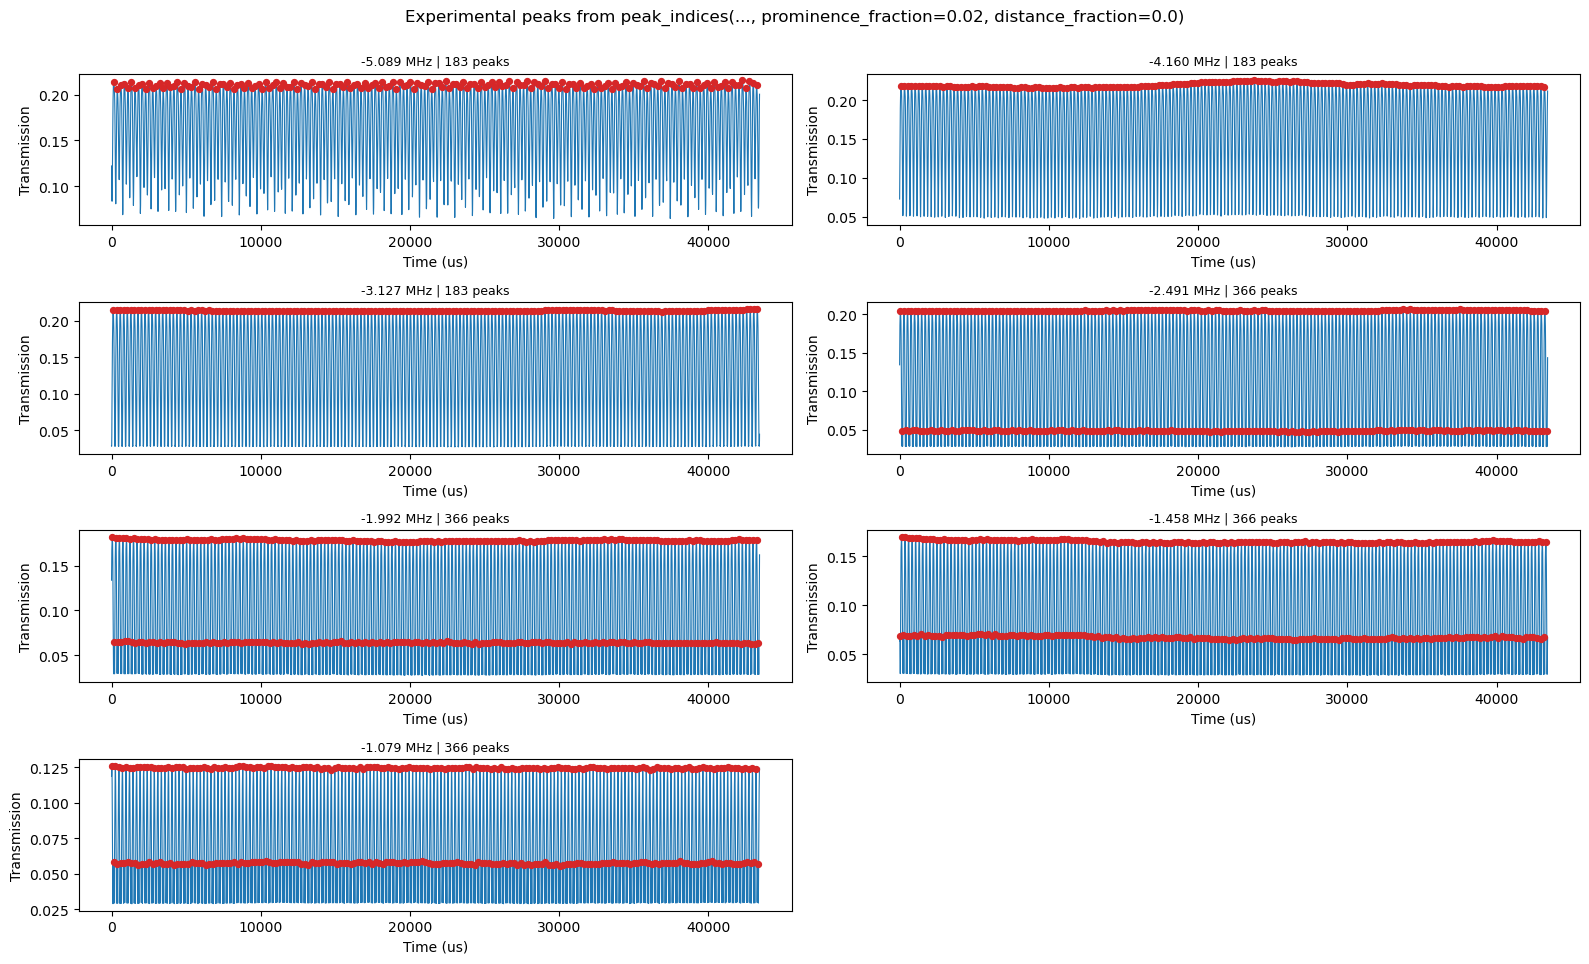

,path,detuning_mhz,detuning_mv,peak_number,peak_index,peak_time_us,peak_value
0,C:\Users\emore\OneDrive\Bouwmeester Group\data...,-5.089047,180,0,34,147.657143,0.213233
1,C:\Users\emore\OneDrive\Bouwmeester Group\data...,-5.089047,180,1,89,386.514286,0.206524
2,C:\Users\emore\OneDrive\Bouwmeester Group\data...,-5.089047,180,2,142,616.685714,0.210277
3,C:\Users\emore\OneDrive\Bouwmeester Group\data...,-5.089047,180,3,197,855.542857,0.211332
4,C:\Users\emore\OneDrive\Bouwmeester Group\data...,-5.089047,180,4,253,1098.742857,0.206748
...,...,...,...,...,...,...,...
2008,C:\Users\emore\OneDrive\Bouwmeester Group\data...,-1.079449,60,361,9863,42833.600000,0.057478
2009,C:\Users\emore\OneDrive\Bouwmeester Group\data...,-1.079449,60,362,9890,42950.857143,0.124866
2010,C:\Users\emore\OneDrive\Bouwmeester Group\data...,-1.079449,60,363,9918,43072.457143,0.057898
2011,C:\Users\emore\OneDrive\Bouwmeester Group\data...,-1.079449,60,364,9944,43185.371429,0.123992


In [158]:
experimental_peaks = []

if not experimental_records:
    print("No experimental records loaded.")
else:
    ncols = 2
    nrows = int(np.ceil(len(experimental_records) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, max(3, 2.4 * nrows)), squeeze=False)

    for ax, record in zip(axes.ravel(), experimental_records):
        time_s, values = finite_sorted_series(record["time_s"], record["values"])
        peaks = peak_indices(
            values,
            prominence_fraction=EXPERIMENT_PEAK_PROMINENCE_FRACTION,
            distance_fraction=EXPERIMENT_MIN_PEAK_DISTANCE_FRACTION,
        )

        ax.plot(time_s * 1e6, values, lw=0.8)
        ax.scatter(time_s[peaks] * 1e6, values[peaks], s=18, color="tab:red", zorder=3)
        ax.set_title(f"{record['detuning_hz'] * 1e-6:.3f} MHz | {len(peaks)} peaks", fontsize=9)
        ax.set_xlabel("Time (us)")
        ax.set_ylabel("Transmission")

        for peak_number, peak_index in enumerate(peaks):
            experimental_peaks.append(
                {
                    "path": str(record["path"]),
                    "detuning_mhz": record["detuning_hz"] * 1e-6,
                    "detuning_mv": record["detuning_mv"],
                    "peak_number": peak_number,
                    "peak_index": int(peak_index),
                    "peak_time_us": float(time_s[peak_index] * 1e6),
                    "peak_value": float(values[peak_index]),
                }
            )

    for ax in axes.ravel()[len(experimental_records):]:
        ax.axis("off")

    fig.suptitle(
        f"Experimental peaks from peak_indices(..., prominence_fraction={EXPERIMENT_PEAK_PROMINENCE_FRACTION}, distance_fraction={EXPERIMENT_MIN_PEAK_DISTANCE_FRACTION})",
        y=1.0,
    )
    fig.tight_layout()
    plt.show()

experimental_peaks_table = pd.DataFrame(experimental_peaks) if pd is not None else experimental_peaks
if pd is not None:
    display(experimental_peaks_table)
else:
    print(f"Found {len(experimental_peaks)} experimental peaks")


In [159]:
simulation_records = load_simulation_records(SIM_SKIP_FIRST_US)


simulation_results = [
    analyze_trace(record, prominence_fraction=SIMULATION_PEAK_PROMINENCE_FRACTION)
    for record in simulation_records
]

Skipping missing simulation: D:\repos\superfluid-dynamics\data\tau\damping\results_detuning_-5.089e+06_pow_3.800e+02_tau_5.500e-05_depth_1.500e-08_L_1.000e-04_dmp_-2.500e+00_gamma_2.000e+07.h5
Skipping missing simulation: D:\repos\superfluid-dynamics\data\tau\damping\results_detuning_-4.160e+06_pow_3.800e+02_tau_5.500e-05_depth_1.500e-08_L_1.000e-04_dmp_-2.500e+00_gamma_2.000e+07.h5
Skipping missing simulation: D:\repos\superfluid-dynamics\data\tau\damping\results_detuning_-3.127e+06_pow_3.800e+02_tau_5.500e-05_depth_1.500e-08_L_1.000e-04_dmp_-2.500e+00_gamma_2.000e+07.h5
Skipping missing simulation: D:\repos\superfluid-dynamics\data\tau\damping\results_detuning_-1.992e+06_pow_3.800e+02_tau_5.500e-05_depth_1.500e-08_L_1.000e-04_dmp_-2.500e+00_gamma_2.000e+07.h5
Skipping missing simulation: D:\repos\superfluid-dynamics\data\tau\damping\results_detuning_-1.458e+06_pow_3.800e+02_tau_5.500e-05_depth_1.500e-08_L_1.000e-04_dmp_-2.500e+00_gamma_2.000e+07.h5
Skipping missing simulation: D:\rep

In [160]:
results = experiment_results + simulation_results

if not results:
    results_table = pd.DataFrame() if pd is not None else []
    print("No experiment or simulation records were loaded. Check the configured data folders above.")
elif pd is not None:
    results_table = pd.DataFrame(results).sort_values(["source", "detuning_mhz", "path"])
    display(results_table)
    results_table.to_csv(OUTPUT_CSV, index=False)
    print(f"Wrote {len(results)} rows to {OUTPUT_CSV}")
else:
    results_table = results
    with open(OUTPUT_CSV, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=results[0].keys())
        writer.writeheader()
        writer.writerows(results)
    print(f"Wrote {len(results)} rows to {OUTPUT_CSV}")

,source,detuning_mhz,detuning_mv,v1,v1_time_us,v2,v2_over_v1,v2_time_us,crossing_count,first_crossing_time_us,method,path
0,experiment,-5.089047,180.0,0.215386,42282.057143,NaN,NaN,NaN,0,NaN,experimental peak-family inference,C:\Users\emore\OneDrive\Bouwmeester Group\data...
1,experiment,-4.159784,160.0,0.225292,23772.800000,NaN,NaN,NaN,0,NaN,experimental peak-family inference,C:\Users\emore\OneDrive\Bouwmeester Group\data...
2,experiment,-3.127270,140.0,0.216400,43272.228571,NaN,NaN,NaN,0,NaN,experimental peak-family inference,C:\Users\emore\OneDrive\Bouwmeester Group\data...
3,experiment,-2.490552,120.0,0.206941,37544.000000,0.050285,0.242994,33631.085714,0,NaN,experimental peak-family inference,C:\Users\emore\OneDrive\Bouwmeester Group\data...
4,experiment,-1.991504,100.0,0.181394,52.114286,0.065885,0.363215,1116.114286,0,NaN,experimental peak-family inference,C:\Users\emore\OneDrive\Bouwmeester Group\data...
5,experiment,-1.458038,80.0,0.169418,130.285714,0.070674,0.417160,5228.800000,0,NaN,experimental peak-family inference,C:\Users\emore\OneDrive\Bouwmeester Group\data...
6,experiment,-1.079449,60.0,0.126197,10692.114286,0.058697,0.465123,10340.342857,0,NaN,experimental peak-family inference,C:\Users\emore\OneDrive\Bouwmeester Group\data...
7,simulation,-2.490552,NaN,138.861969,64880.500000,4.488451,0.032323,64752.000000,181,42058.539177,simulation delta_f zero crossing,D:\repos\superfluid-dynamics\data\tau\damping\...


Wrote 8 rows to D:\repos\superfluid-dynamics\CuSuperHelium\Python\analysis_rhs\resonance_peak_summary.csv


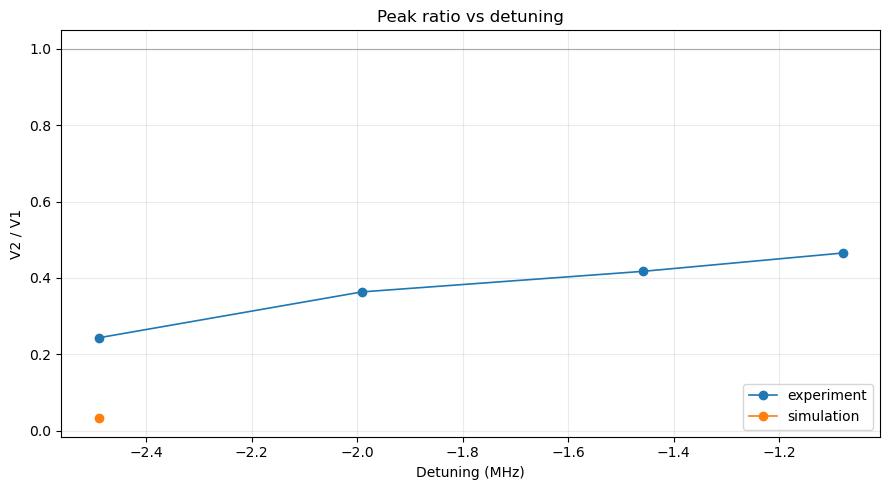

,source,detuning_mhz,detuning_mv,v1,v2,v2_over_v1,path
0,experiment,-2.490552,120.0,0.206941,0.050285,0.242994,C:\Users\emore\OneDrive\Bouwmeester Group\data...
1,experiment,-1.991504,100.0,0.181394,0.065885,0.363215,C:\Users\emore\OneDrive\Bouwmeester Group\data...
2,experiment,-1.458038,80.0,0.169418,0.070674,0.417160,C:\Users\emore\OneDrive\Bouwmeester Group\data...
3,experiment,-1.079449,60.0,0.126197,0.058697,0.465123,C:\Users\emore\OneDrive\Bouwmeester Group\data...
4,simulation,-2.490552,NaN,138.861969,4.488451,0.032323,D:\repos\superfluid-dynamics\data\tau\damping\...


In [161]:
def ratio_records_for_plot(results):
    rows = []
    for row in results:
        ratio = row.get("v2_over_v1", np.nan)
        detuning_mhz = row.get("detuning_mhz", np.nan)
        if not np.isfinite(ratio) or not np.isfinite(detuning_mhz):
            continue
        rows.append(row)
    return rows


ratio_plot_records = ratio_records_for_plot(results)

if not ratio_plot_records:
    print("No finite V2/V1 ratios to plot.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    for source in sorted({row["source"] for row in ratio_plot_records}):
        source_rows = [row for row in ratio_plot_records if row["source"] == source]
        source_rows = sorted(source_rows, key=lambda row: row["detuning_mhz"])
        detuning_mhz = np.array([row["detuning_mhz"] for row in source_rows])
        ratios = np.array([row["v2_over_v1"] for row in source_rows])
        ax.plot(detuning_mhz, ratios, marker="o", lw=1.2, label=source)

    ax.set_xlabel("Detuning (MHz)")
    ax.set_ylabel("V2 / V1")
    ax.set_title("Peak ratio vs detuning")
    ax.axhline(1.0, color="0.4", lw=0.8, alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()
    plt.show()

ratio_table = pd.DataFrame(ratio_plot_records) if pd is not None else ratio_plot_records
    
if pd is not None and ratio_plot_records:
    display(ratio_table[["source", "detuning_mhz", "detuning_mv", "v1", "v2", "v2_over_v1", "path"]])


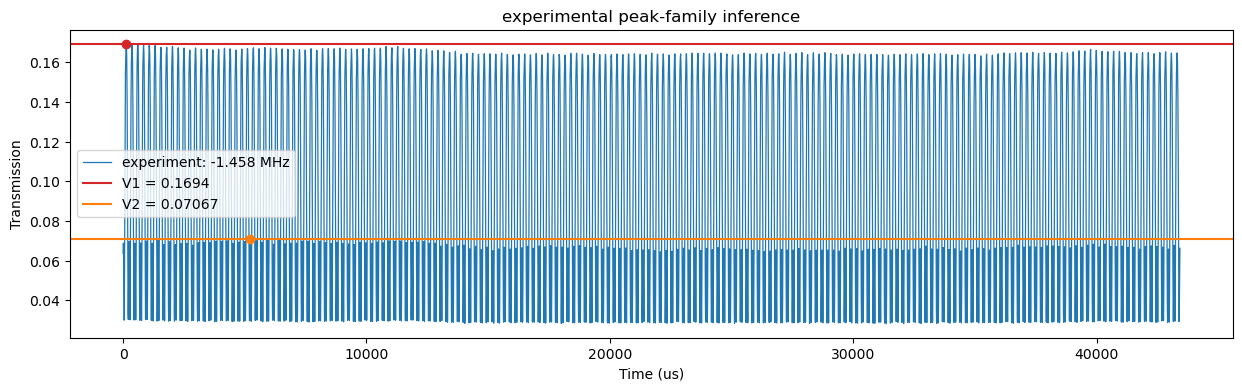

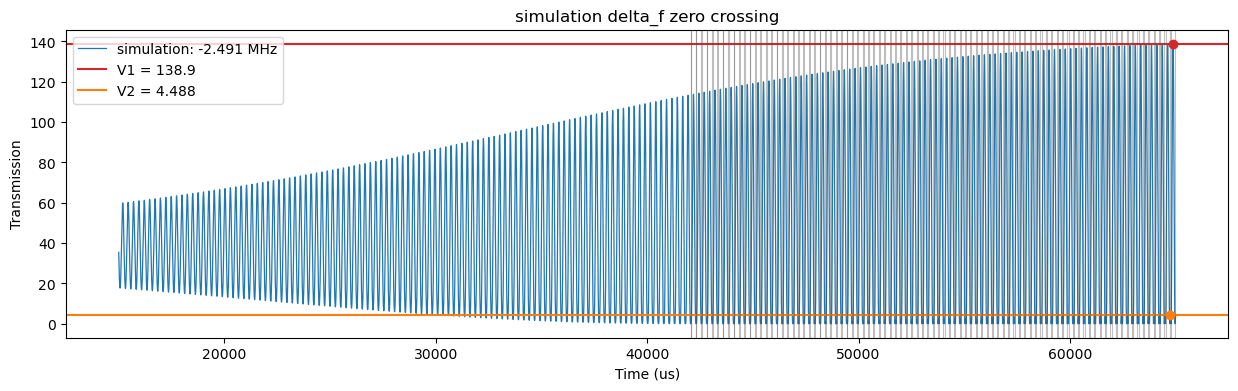

In [162]:
def plot_trace_analysis(record, result=None, prominence_fraction=0.05, ax=None):
    if result is None:
        result = analyze_trace(record, prominence_fraction=prominence_fraction)

    time_us = np.asarray(record["time_s"]) * 1e6
    values = np.asarray(record["values"])

    if ax is None:
        _, ax = plt.subplots(figsize=(15, 4))

    ax.plot(time_us, values, lw=0.9, label=f"{record['source']}: {result['detuning_mhz']:.3f} MHz")
    ax.axhline(result["v1"], color="tab:red", lw=1.5, label=f"V1 = {result['v1']:.4g}")
    ax.scatter(result["v1_time_us"], result["v1"], color="tab:red", zorder=3)

    if np.isfinite(result["v2"]):
        ax.axhline(result["v2"], color="tab:orange", lw=1.5, label=f"V2 = {result['v2']:.4g}")
        ax.scatter(result["v2_time_us"], result["v2"], color="tab:orange", zorder=3)

    if "resonance_signal" in record:
        for t_cross in crossing_times(record["time_s"], record["resonance_signal"]):
            ax.axvline(t_cross * 1e6, color="0.3", lw=0.8, alpha=0.35)

    ax.set_xlabel("Time (us)")
    ax.set_ylabel("Transmission")
    ax.set_title(result["method"])
    ax.legend(loc="best")
    return ax

i = 5
if experimental_records:
    plot_trace_analysis(experimental_records[i], experiment_results[i], EXPERIMENT_PEAK_PROMINENCE_FRACTION)

if simulation_records:
    plot_trace_analysis(simulation_records[0], simulation_results[0], SIMULATION_PEAK_PROMINENCE_FRACTION)

plt.show()

If the experimental `V2` marker lands on the wrong peak family, tune `EXPERIMENT_PEAK_PROMINENCE_FRACTION` or inspect a single trace with `plot_trace_analysis(experimental_records[i])`. The simulation result is stricter because it uses the calculated `delta_f = detuning - df` zero crossing.